In [1]:
import pandas as pd

# Path katalog noise
noise_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/input/query_usgs_noise_indonesia.csv"

# Load data
noise_df = pd.read_csv(noise_path)

# Tampilkan struktur kolom
print(noise_df.columns)
print(noise_df.head())


Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type',
       'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')
                       time  latitude  longitude  depth  mag magType  nst  \
0  2014-11-06T22:12:27.880Z  -21.7816   122.2952      0  3.4      mb  NaN   
1  2025-07-07T03:05:15.000Z   -8.5510   122.7800      0  3.0      ml  0.0   

     gap   dmin   rms  ...                   updated  \
0  126.0  2.287  0.95  ...  2015-01-31T02:50:05.040Z   
1    NaN    NaN  0.09  ...  2025-09-12T16:23:10.040Z   

                                  place               type horizontalError  \
0       118 km WSW of Telfer, Australia   mining explosion             3.7   
1  Mount Lewotobi Laki-Laki, Indonesia   volcanic eruption            16.8   

  depthError  magError  magNst    status  locationSource magSource  
0      2.000     0

In [2]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Load noise
noise_path = "/Volumes/Local Disk/Code_Git/S3_code/seismic/mcu_quake/code_gen_trying/indonesia_jaya_benchmarking_data/input/query_usgs_noise_indonesia.csv"
noise_df = pd.read_csv(noise_path)

# Load shapefile Indonesia
world = gpd.read_file("ne_110m_admin_0_countries/ne_110m_admin_0_countries.shp")
indo_poly = world[world['ADMIN'] == 'Indonesia']
indo_buffer = indo_poly.to_crs("EPSG:4326").buffer(2)

# Convert to GeoDataFrame
noise_gdf = gpd.GeoDataFrame(
    noise_df,
    geometry=gpd.points_from_xy(noise_df.longitude, noise_df.latitude),
    crs="EPSG:4326"
)

# Filter noise dalam Indonesia + buffer
indo_noise = noise_gdf[noise_gdf.within(indo_buffer.unary_union)]
print("Total noise Indonesia:", len(indo_noise))


Total noise Indonesia: 1


/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_45962/2928434125.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  indo_buffer = indo_poly.to_crs("EPSG:4326").buffer(2)
/var/folders/lt/2mkl6ry53ll9fdk2br6skfgw0000gn/T/ipykernel_45962/2928434125.py:22: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  indo_noise = noise_gdf[noise_gdf.within(indo_buffer.unary_union)]


In [4]:
noise_only = indo_noise[indo_noise['type'].isin([
    "mining explosion",
    "volcanic eruption",
    "quarry blast",
    "explosion",
    "other event",
    "chemical explosion",
    "rock burst",
    "sonic boom"
])]


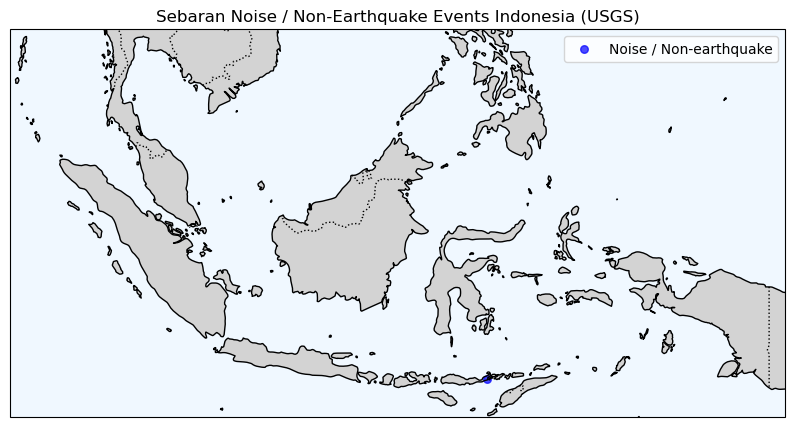

In [5]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

plt.figure(figsize=(10, 12))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([92, 142, -11, 14], crs=ccrs.PlateCarree())

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.BORDERS, linestyle=":")
ax.add_feature(cfeature.LAND, facecolor="lightgray")
ax.add_feature(cfeature.OCEAN, facecolor="aliceblue")

# Plot noise
ax.scatter(
    noise_only["longitude"], noise_only["latitude"],
    s=30, c="blue", alpha=0.7,
    transform=ccrs.PlateCarree(),
    label="Noise / Non-earthquake"
)

plt.title("Sebaran Noise / Non-Earthquake Events Indonesia (USGS)")
plt.legend()
plt.show()
